In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import scipy.stats as sps
from pathlib import Path
import os
import re

In [2]:
from data_analysis import *
from data_extraction import *
from myprobs import *

In [3]:
default_figsize = (12, 10)
figure_dir = "/home/erdi/Uni/LCGAStage/CleanLagrangianLaminarJet/Figures/"

111mm test
NEED THE DIAMETERS IN METERS
area under diameter prob dist   = 0.999857142857143
area under m distribution       = 0.9962142857142856
area under d prob*volume        = 0.999649092780565


AttributeError: 'MyProbs' object has no attribute 'd_actual_probability'

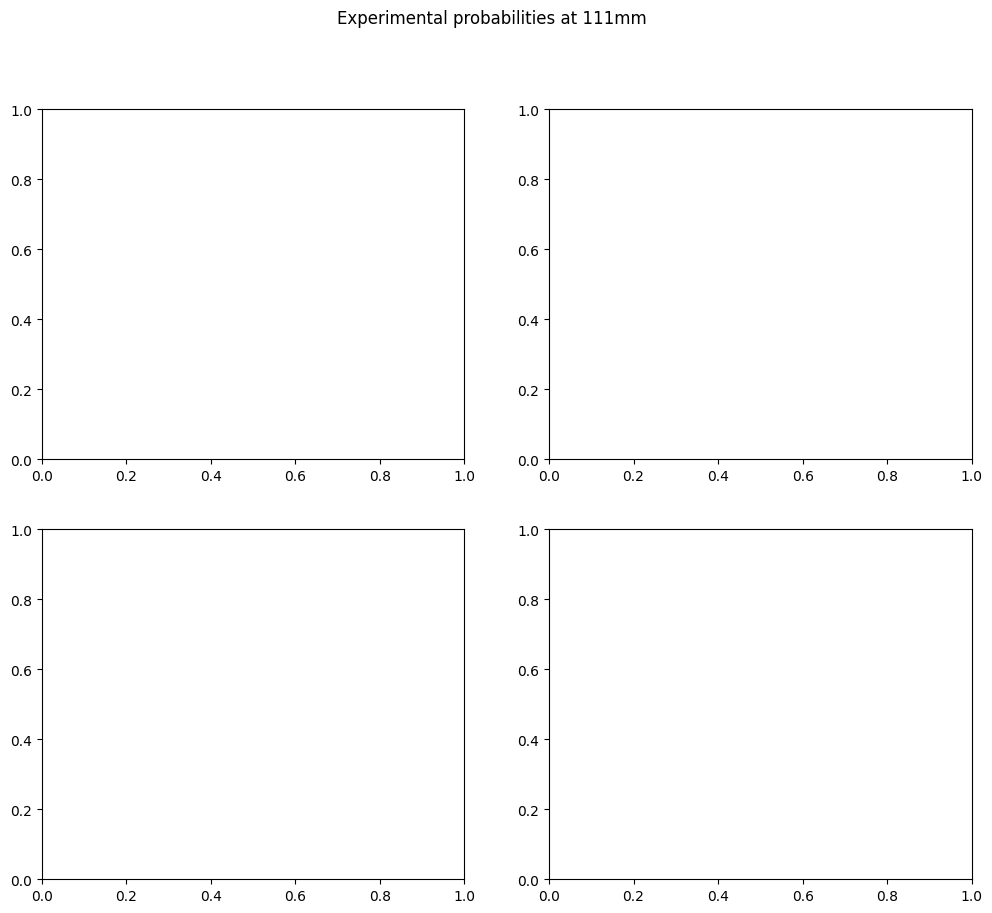

In [5]:
def plotDiameterComparisonsColors(to_plot, log=False, str_dia="", figsize=(12, 10), cmap="plasma"):
    fig, axs = plt.subplots(2, 2, figsize=figsize)
    ((ax0, ax1), (ax2, ax3)) = axs 
    fig.suptitle("Experimental probabilities at 111mm")
    
    print("area under actual diameter prob =", np.trapezoid(to_plot.d_actual_probability, to_plot.d_prob_dist_bin_centers))
    print("area under diameter prob dist   =", np.trapezoid(to_plot.d_prob_density, to_plot.d_prob_dist_bin_centers))
    print("area under m actual prob        =", np.trapezoid(to_plot.m_actual_probability, to_plot.m_prob_dist_bin_centers))
    print("area under m distribution       =", np.trapezoid(to_plot.m_prob_density, to_plot.m_prob_dist_bin_centers))
    print("area under d prob*volume        =", np.trapezoid(to_plot.d_vol_weighted_ptob_dist, to_plot.d_prob_weighted_dist_bin_centers))
    
    marker_area = 15 

    x0 = to_plot.d_prob_dist_bin_centers * 1e6
    ax0.plot(x0, to_plot.d_actual_probability, color='gray', alpha=0.3, zorder=1) 
    ax0.plot(x0, to_plot.d_prob_density * 1e-6  , color='gray', alpha=0.3, zorder=1)
    sc0_1 = ax0.scatter(x0, to_plot.d_actual_probability, c=x0, cmap=cmap, s=marker_area, zorder=2               , label="Actual probability")
    sc0_2 = ax0.scatter(x0, to_plot.d_prob_density * 1e-6  , c=x0, cmap=cmap, s=marker_area, zorder=2, marker='^', label="Probability density")
    # fig.colorbar(sc0_1, ax=ax0, label="d [µm]") # Add colorbar to this axis

    x1 = to_plot.d_prob_weighted_dist_bin_centers * 1e6
    ax1.plot(         x1, to_plot.d_vol_weighted_ptob_dist * 1e-6, color='gray', alpha=0.3       , zorder=1)
    sc1 = ax1.scatter(x1, to_plot.d_vol_weighted_ptob_dist * 1e-6, c=x0, cmap=cmap, s=marker_area, zorder=2)
    # fig.colorbar(sc1, ax=ax1, label="d [µm]")

    x2 = to_plot.m_prob_dist_bin_centers * 1e9
    ax2.plot(         x2, to_plot.m_actual_probability, color='gray', alpha=0.3       , zorder=1)
    sc2 = ax2.scatter(x2, to_plot.m_actual_probability, c=x0, cmap=cmap, s=marker_area, zorder=2)
    # fig.colorbar(sc2, ax=ax2, label="d [µm]")

    x3 = to_plot.m_prob_dist_bin_centers * 1e9
    ax3.plot(         x3, to_plot.m_prob_density, color='gray', alpha=0.3, zorder=1)
    sc3 = ax3.scatter(x3, to_plot.m_prob_density, c=x0, cmap=cmap, s=marker_area, zorder=2)
    # fig.colorbar(sc3, ax=ax3, label="d [µm]")

    for tup_ax in axs:
        for ax in tup_ax: 
            if ax == ax2 or ax == ax3:
                ax.axvline(x=12e-1, color="k", linestyle="--")
            else: 
                ax.axvline(x=massToRadius(12e-1*1e-9) * 2 * 1e6, color="k", linestyle="--")
                
    if log: 
        for ax in [ax0, ax1, ax2, ax3]:
            ax.set_yscale('log')
            
    ax0.legend()
    ax0.set_title("Diameter")
    ax1.set_title("Volume weighted diameter probability density")
    ax2.set_title("Mass probability")
    ax3.set_title("Mass probability density")
    
    ax0.set_xlabel("d [µm]")
    ax1.set_xlabel("d [µm]")
    ax2.set_xlabel("M [µg]")
    ax3.set_xlabel("M [µg]") 
    
    # TODO add gamma and frichebourg fit 
    ax2.set_xlim([0, 20])
    ax2.set_xticks([i for i in range(0, 21, 5)])
    ax3.set_xlim([0, 20])
    ax3.set_xticks([i for i in range(0, 21, 5)])
    
    plt.tight_layout()
    plt.savefig(figure_dir +str_dia+ f"quadro_comp_exp_colors_log{log}.pdf")
# plotDiameterComparisonsColors()
test111 = MyProbs.initFromFolder("/home/erdi/Uni/LCGAStage/CleanLagrangianLaminarJet/Code/OutF2925X111_8", "111mm test")
plotDiameterComparisonsColors(test111, log=True)